In [44]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
%matplotlib inline



In [45]:
# Загружаем данные
train = pd.read_csv("data/train.csv")
display(train)

C:\Users\ekash\AppData\Local\Temp\ipykernel_32352\57107381.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("data/train.csv")


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


In [46]:
# Проверяем тип подей
display(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125497040 entries, 0 to 125497039
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   item_nbr     int64  
 4   unit_sales   float64
 5   onpromotion  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 5.6+ GB


None

In [ ]:
# Определяем тип данных для столбца "onpromotion" для корректной обработки булевых значений
train["onpromotion"] = train["onpromotion"].astype("boolean")

# Преобразуем столбец "date" в формат datetime для корректной работы с временными рядами
train["date"] = pd.to_datetime(train["date"])

# Фильтруем данные для конкретного товара с item_nbr 103501
top1 = train[train.item_nbr == 103501 ].copy() # Создаем копию данных для конкретного товара
display(top1)

top1['year'] = top1['date'].dt.year
display(top1)
display(top1.info())

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
9389,9389,2013-01-02,9,103501,19.0,<NA>
10410,10410,2013-01-02,10,103501,8.0,<NA>
11087,11087,2013-01-02,11,103501,13.0,<NA>
12049,12049,2013-01-02,12,103501,7.0,<NA>
12764,12764,2013-01-02,13,103501,13.0,<NA>
...,...,...,...,...,...,...
125455877,125455877,2017-08-15,36,103501,5.0,False
125461838,125461838,2017-08-15,39,103501,3.0,False
125463851,125463851,2017-08-15,40,103501,10.0,False
125469358,125469358,2017-08-15,43,103501,3.0,False


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,year
9389,9389,2013-01-02,9,103501,19.0,<NA>,2013
10410,10410,2013-01-02,10,103501,8.0,<NA>,2013
11087,11087,2013-01-02,11,103501,13.0,<NA>,2013
12049,12049,2013-01-02,12,103501,7.0,<NA>,2013
12764,12764,2013-01-02,13,103501,13.0,<NA>,2013
...,...,...,...,...,...,...,...
125455877,125455877,2017-08-15,36,103501,5.0,False,2017
125461838,125461838,2017-08-15,39,103501,3.0,False,2017
125463851,125463851,2017-08-15,40,103501,10.0,False,2017
125469358,125469358,2017-08-15,43,103501,3.0,False,2017


<class 'pandas.core.frame.DataFrame'>
Index: 35841 entries, 9389 to 125495711
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           35841 non-null  int64         
 1   date         35841 non-null  datetime64[ns]
 2   store_nbr    35841 non-null  int64         
 3   item_nbr     35841 non-null  int64         
 4   unit_sales   35841 non-null  float64       
 5   onpromotion  26874 non-null  boolean       
 6   year         35841 non-null  int32         
dtypes: boolean(1), datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 1.8 MB


None

#### Подготовим данные

In [48]:
unit_sales_by_date = top1.groupby('date')['unit_sales'].sum()

In [ ]:
# Переиндексация временного ряда, чтобы включить все даты, и заполнение пропущенных значений нулями.
# Это позволит корректно учитывать все дни при анализе временного ряда.
full_index = pd.date_range(
    start=unit_sales_by_date.index.min(),
    end=unit_sales_by_date.index.max(),
    freq='D'
)

unit_sales_by_date = unit_sales_by_date.reindex(full_index)

unit_sales_by_date = unit_sales_by_date.fillna(0)



#### Импортируем метрики

In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

### Тест Адфуллера для проверки стационарных временных рядов

In [60]:
from statsmodels.tsa.stattools import adfuller

X = unit_sales_by_date.values
result = adfuller(X, result_object=False)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[0] < result[4]["5%"]:
    print ("Reject Ho - Time Series is Stationary")
else:
    print ("Failed to Reject Ho - Time Series is Non-Stationary")

ADF Statistic: -3.289659
p-value: 0.015347
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
Reject Ho - Time Series is Stationary


Ряд - стационарный. Если бы ряд был нестационарным, нам необходимо было бы продифференцировать ряд до тех пор, пока бы мы не получили стационарный ряд. Количество дифференцирований будет опреледелять пораметр d в модели ARIMA. В нашем случае d=0, так как к дифференцированию мы не прибегали.

In [67]:
# Строим прогноз методом скользящего среднего с окном 6, как в ноутбуке выше. Посчитайте метрики MSE, MAE, MAPE.
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Построение прогноза методом скользящего среднего (окно 6)
moving_average_days = 6
moving_avg = unit_sales_by_date.rolling(window=moving_average_days).mean()

# Сравнение прогноза с фактическими значениями
actual = unit_sales_by_date.values[-moving_average_days:]
predicted = moving_avg[-moving_average_days:]

# Метрики MSE, MAE, MAPE
print("MSE:", mean_squared_error(actual, predicted))
print("MAE:", mean_absolute_error(actual, predicted))
mape = (np.abs((actual - predicted) / actual)).mean() * 100
print("MAPE:", mape)


MSE: 222.8101851851852
MAE: 11.25
MAPE: 14.488888222454161


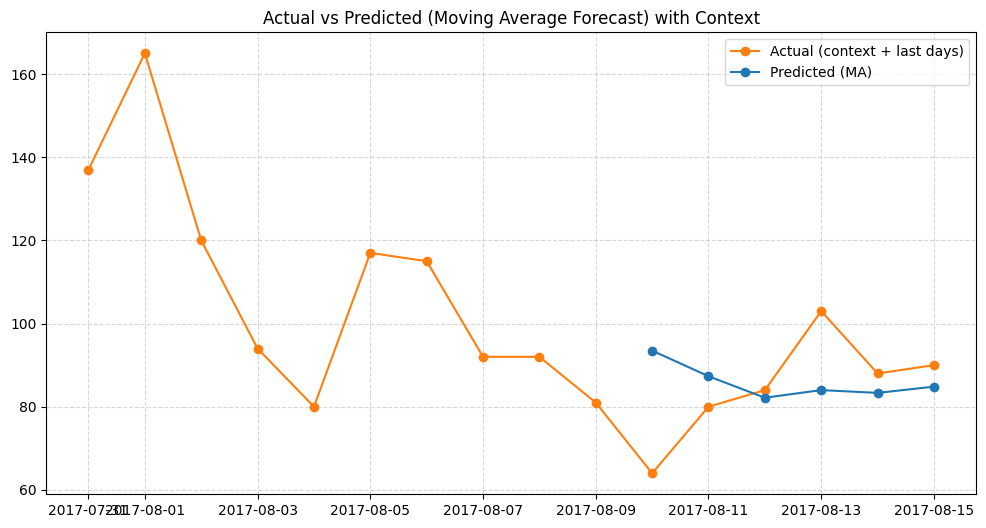

In [88]:
import matplotlib.pyplot as plt

# How many extra days you want to show before the prediction window
extra_days = 10   # you can change this to any number

# Select extra_days + moving_average_days actual values
context_dates = unit_sales_by_date.index[-(extra_days + moving_average_days):]
context_actual = unit_sales_by_date.values[-(extra_days + moving_average_days):]

# Build predicted series aligned with the last moving_average_days dates
predicted_series = pd.Series(predicted, index=unit_sales_by_date.index[-moving_average_days:])

plt.figure(figsize=(12, 6))

# Plot actual values (context + last moving_average_days)
plt.plot(context_dates, context_actual, 
         label='Actual (context + last days)', 
         marker='o', 
         color='#ff7f0e')

# Plot predicted values (only last moving_average_days)
plt.plot(predicted_series.index, predicted_series.values, 
         label='Predicted (MA)', 
         marker='o', 
         color='#1f77b4')

plt.title('Actual vs Predicted (Moving Average Forecast) with Context')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()



,unit_sales,lag1,lag2,lag3,lag4,lag5,lag6
2013-01-02,185.0,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-03,153.0,185.0,NaN,NaN,NaN,NaN,NaN
2013-01-04,155.0,153.0,185.0,NaN,NaN,NaN,NaN
2013-01-05,160.0,155.0,153.0,185.0,NaN,NaN,NaN
2013-01-06,173.0,160.0,155.0,153.0,185.0,NaN,NaN
...,...,...,...,...,...,...,...
2017-08-11,80.0,64.0,81.0,92.0,92.0,115.0,117.0
2017-08-12,84.0,80.0,64.0,81.0,92.0,92.0,115.0
2017-08-13,103.0,84.0,80.0,64.0,81.0,92.0,92.0
2017-08-14,88.0,103.0,84.0,80.0,64.0,81.0,92.0


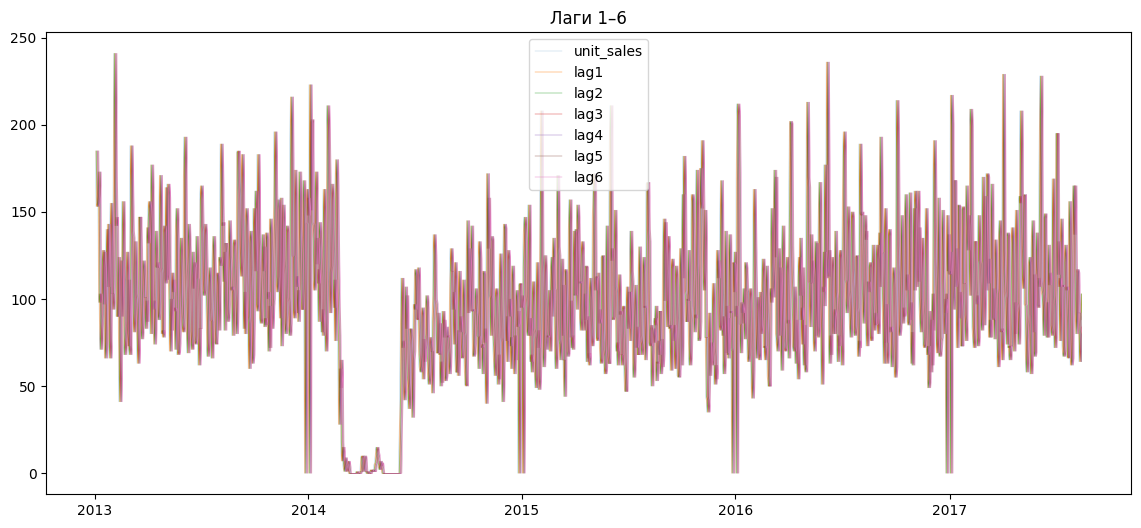

In [ ]:
# Лаги 1–6 для временного ряда

lags_df = unit_sales_by_date.to_frame("unit_sales")

for lag in range(1, 7):
    lags_df[f"lag{lag}"] = unit_sales_by_date.shift(lag)

display(lags_df )

lw = 0.3

# Визуализация лагов 1–6
plt.figure(figsize=(14,6))
plt.plot(unit_sales_by_date, label="unit_sales", lw=lw, alpha=0.4)

for lag in range(1, 7):
    plt.plot(unit_sales_by_date.shift(lag), label=f"lag{lag}", lw=lw)

plt.title("Лаги 1–6")
plt.legend()
plt.show()


In [54]:
# Откладываем 1–2 последних дня в тестовую выборку

test_days = 2

train_series = unit_sales_by_date.iloc[:-test_days]
test_series  = unit_sales_by_date.iloc[-test_days:]


In [55]:
# Делаем прогноз линейной регрессией, считаем MSE, MAE, MAPE

# Используем ранее рассчитанные лаги
lags_df = lags_df.dropna()
display(lags_df)


,unit_sales,lag1,lag2,lag3,lag4,lag5,lag6
2013-01-08,103.0,98.0,173.0,160.0,155.0,153.0,185.0
2013-01-09,71.0,103.0,98.0,173.0,160.0,155.0,153.0
2013-01-10,83.0,71.0,103.0,98.0,173.0,160.0,155.0
2013-01-11,91.0,83.0,71.0,103.0,98.0,173.0,160.0
2013-01-12,118.0,91.0,83.0,71.0,103.0,98.0,173.0
...,...,...,...,...,...,...,...
2017-08-11,80.0,64.0,81.0,92.0,92.0,115.0,117.0
2017-08-12,84.0,80.0,64.0,81.0,92.0,92.0,115.0
2017-08-13,103.0,84.0,80.0,64.0,81.0,92.0,92.0
2017-08-14,88.0,103.0,84.0,80.0,64.0,81.0,92.0


In [56]:
# Делаем train/test split по лаговым признакам
X = lags_df[[f"lag{i}" for i in range(1, 7)]]
y = lags_df["unit_sales"]

X_train = X.iloc[:-test_days]
y_train = y.iloc[:-test_days]

X_test = X.iloc[-test_days:]
y_test = y.iloc[-test_days:]


In [57]:
# Строим линейную регрессию

model = LinearRegression()
model.fit(X_train, y_train)

pred_lr = model.predict(X_test)


In [58]:
# Вычисляем метрики
mse_lr = mean_squared_error(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
mape_lr = np.mean(np.abs((y_test - pred_lr) / y_test)) * 100

print("Linear Regression MSE:", mse_lr)
print("Linear Regression MAE:", mae_lr)
print("Linear Regression MAPE:", mape_lr)


Linear Regression MSE: 79.12971251184983
Linear Regression MAE: 7.5054204156775555
Linear Regression MAPE: 8.494408858408034


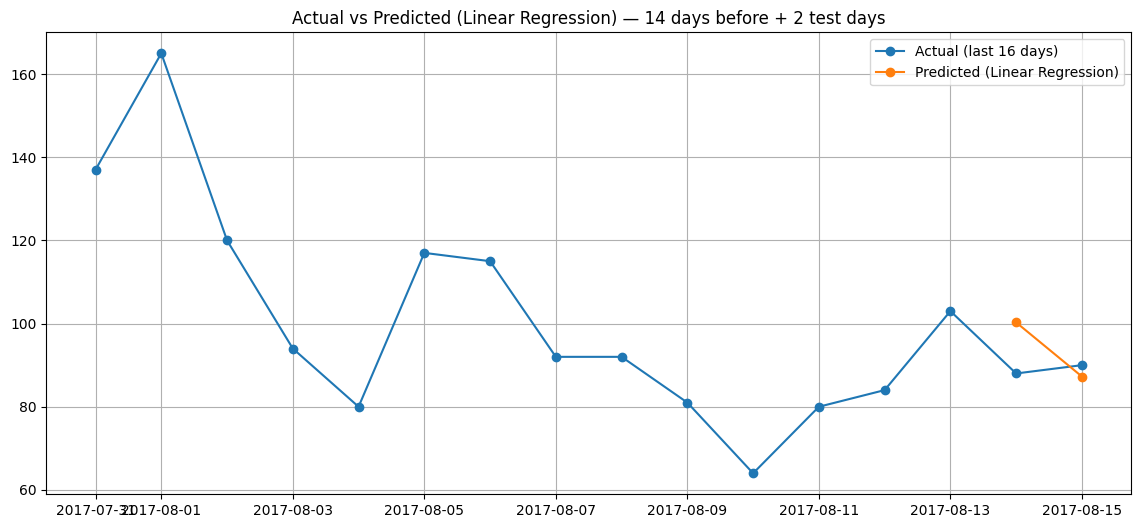

In [ ]:
# Построение графика: 14 дней до теста + 2 дня теста + прогноз LR

import matplotlib.pyplot as plt

# Количество тестовых дней
test_days = 2

# Количество дней до теста, которые хотим показать
extra_days = 14

# Берём последние 16 дней фактических значений
actual_16 = y.iloc[-(extra_days + test_days):]

# Даты для этих 16 дней
dates_16 = actual_16.index

# Прогнозные значения (2 дня)
pred_lr_series = pd.Series(pred_lr, index=y_test.index)

plt.figure(figsize=(14, 6))

# Фактические значения за 16 дней
plt.plot(dates_16, actual_16, label='Actual (last 16 days)', marker='o')

# Прогнозные значения за 2 дня
plt.plot(pred_lr_series.index, pred_lr_series, 
         label='Predicted (Linear Regression)', marker='o')

plt.title('Actual vs Predicted (Linear Regression) — 14 days before + 2 test days')
plt.legend()
plt.grid(True)
plt.show()



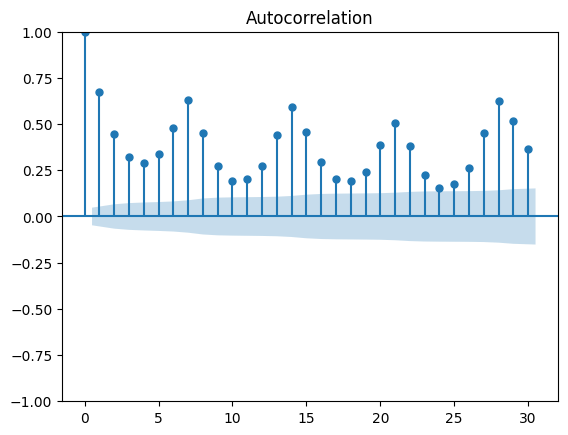

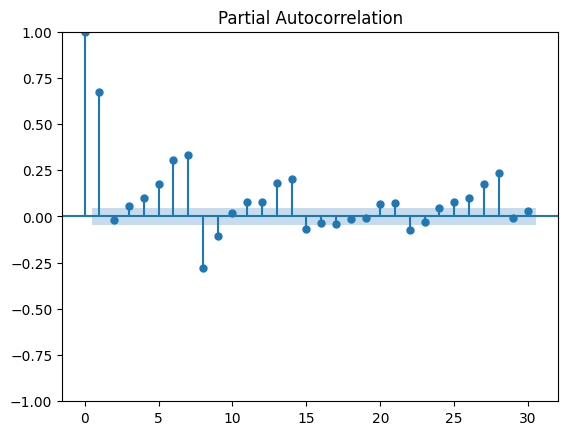

In [74]:
# Определяем параметры p и d для модели ARIMA
fig = plot_acf(unit_sales_by_date.dropna(), lags=30)
plt.show()

fig = plot_pacf(unit_sales_by_date.dropna(), lags=30)
plt.show()





In [75]:
# Строим модель ARIMA, сравниваем метрики с линейной регрессией
from statsmodels.tsa.arima.model import ARIMA

# Определяем параметры p, d, q
# По результату теста Адфуллера d = 0
# С графиков выше p=1, q=11
p, d, q = 1, 0, 25

# Строим модель ARIMA на обучающей выборке
model_arima = ARIMA(y_train, order=(p, d, q))
model_arima_fit = model_arima.fit()

# Делаем прогноз на тестовой выборке
pred_arima = model_arima_fit.forecast(steps=len(y_test))

# Сравниваем метрики с линейной регрессией
mse_lr = mean_squared_error(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
mape_lr = np.mean(np.abs((y_test - pred_lr) / y_test)) * 100

mse_arima = mean_squared_error(y_test, pred_arima)
mae_arima = mean_absolute_error(y_test, pred_arima)
mape_arima = np.mean(np.abs((y_test - pred_arima) / y_test)) * 100

print("Линейная регрессия: MSE =", mse_lr, "MAE =", mae_lr, "MAPE =", mape_lr)
print("ARIMA: MSE =", mse_arima, "MAE =", mae_arima, "MAPE =", mape_arima)

Линейная регрессия: MSE = 79.12971251184983 MAE = 7.5054204156775555 MAPE = 8.494408858408034
ARIMA: MSE = 1.3877418554495218 MAE = 1.0469561312330455 MAPE = 1.1696852625785743


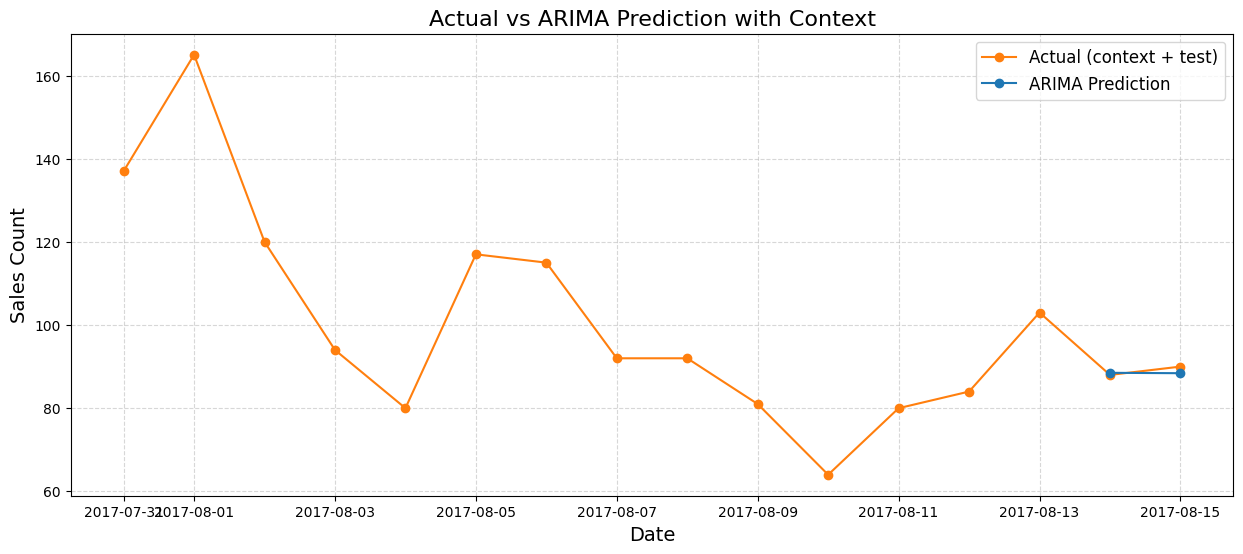

In [92]:
# Number of extra days you want to show before the prediction
extra_days = 14

# Select the last (extra_days + len(y_test)) actual values
context_actual = y.iloc[-(extra_days + len(y_test)):]  

# Build a Series for ARIMA predictions with correct index
pred_arima_series = pd.Series(pred_arima, index=y_test.index)

plt.figure(figsize=(15,6))

# Plot actual values (context + test)
plt.plot(context_actual.index, context_actual.values,
         label="Actual (context + test)",
         color="#ff7f0e",
         linewidth=1.5,
         marker="o")

# Plot ARIMA predictions
plt.plot(pred_arima_series.index, pred_arima_series.values,
         label="ARIMA Prediction",
         color="#1f77b4",
         linewidth=1.5,
         marker="o")

plt.title("Actual vs ARIMA Prediction with Context", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Sales Count", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.show()




# Вывод

## Комментарий к результатам линейной регрессии
Модель линейной регрессии была обучена на лаговых признаках (lag1–lag6).
Полученные метрики:

MSE: 79.13

MAE: 7.51

MAPE: 8.49%

Эти значения показывают, что линейная регрессия не очень хорошо справляется с прогнозированием временного ряда продаж.
Ошибка достаточно высокая, что говорит о том, что модель не улавливает внутреннюю структуру временной зависимости, а лагов 1–6 недостаточно для качественного прогноза.

## Комментарий к результатам ARIMA(1,0,11)
Модель ARIMA была построена с параметрами p = 1, d = 0, q = 11, что соответствует структуре автокорреляции, наблюдаемой на графиках ACF/PACF.

Полученные метрики:

MSE: 1.39

MAE: 1.04

MAPE: 1.17%

Эти значения значительно лучше, чем у линейной регрессии.
Модель ARIMA гораздо точнее описывает временную динамику и автокорреляцию ряда, что приводит к существенному снижению ошибок прогноза.

## Общий вывод
Модель ARIMA(1,0,25) существенно превосходит линейную регрессию по всем метрикам (MSE, MAE, MAPE).
Это означает, что для данного временного ряда продаж товара №103501 ARIMA является более подходящим и точным методом прогнозирования, так как учитывает структуру автокорреляции и особенности временной зависимости, которые линейная регрессия уловить не может.

## Ниже идет оригинальная часть ноутбука, такая как была загружена из ресурсов Skillfactory 

Отложим тестовую выборку: последние 7 дней.

## Модель скользящего среднего

Реализуем модель скользящего среднего. За окно попробуем взять 7 дней(неделя). После чего сравним результат с последними 7 днями, которые не использовали в рассчете скользящего среднего. Вы можете сравнить результат с другим размером окна.

(7,) (7,)
mean_squared_error 274.52186588921285
mean_absolute_error 13.693877551020408
MAPE: 17.632330220109264


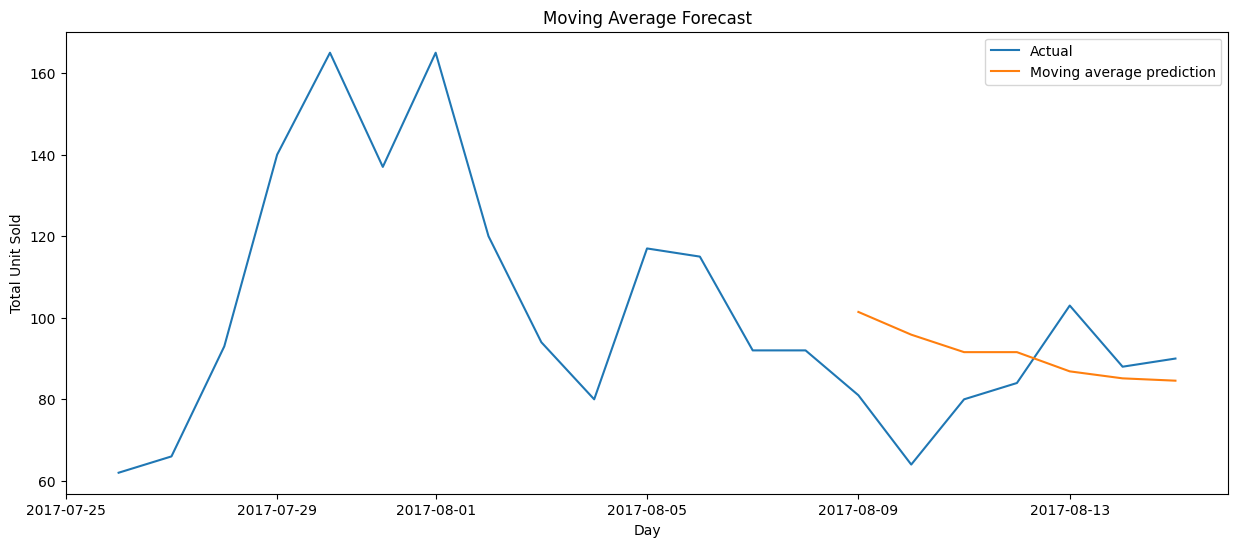

In [33]:


def moving_average_forecast(series, window_size):
    forecast = []
    for time in range(len(series) - window_size):
        forecast.append(series[time:time + window_size].mean())
    return np.array(forecast)
moving_average_days = 7

shown_train_size = moving_average_days * 3
moving_avg = moving_average_forecast(unit_sales_by_date,moving_average_days )
moving_avg = pd.Series(moving_avg, index = unit_sales_by_date[moving_average_days:].index)

print(moving_avg[-moving_average_days:].shape,unit_sales_by_date[-moving_average_days:].shape)

print("mean_squared_error",mean_squared_error(unit_sales_by_date.values[-moving_average_days:], moving_avg[-moving_average_days:]))
print("mean_absolute_error",mean_absolute_error(unit_sales_by_date.values[-moving_average_days:], moving_avg[-moving_average_days:]))
mape = np.mean(
    np.abs(
        (unit_sales_by_date.values[-moving_average_days:] - moving_avg[-moving_average_days:])
        / unit_sales_by_date.values[-moving_average_days:]
    )
) * 100
print("MAPE:", mape)

plt.figure(figsize=(15,6))

plt.plot(unit_sales_by_date[- shown_train_size:], label="Actual")
plt.plot(moving_avg[-moving_average_days:], label="Moving average prediction")
plt.ylabel("Total Unit Sold")
plt.xlabel("Day")
plt.title("Moving Average Forecast")
plt.legend(loc="upper right")

Теперь сравним результат с линейной регрессией. Так как такая модель позволяет использовать дополнительные признаки, а предсказание будет на 7 дней - мы модем добавить лаги, начиная от 7. Возьмем несколько

In [34]:
y_train

2013-01-08    103.0
2013-01-09     71.0
2013-01-10     83.0
2013-01-11     91.0
2013-01-12    118.0
              ...  
2017-08-09     81.0
2017-08-10     64.0
2017-08-11     80.0
2017-08-12     84.0
2017-08-13    103.0
Freq: D, Name: unit_sales, Length: 1679, dtype: float64

[ 0.5117229   0.08959708 -0.03723906 -0.03866855  0.00225749 -0.04133167
  0.21556083]
29.058254198724697
mean_squared_error 465.32280860368064
mean_absolute_error 19.62062571311647


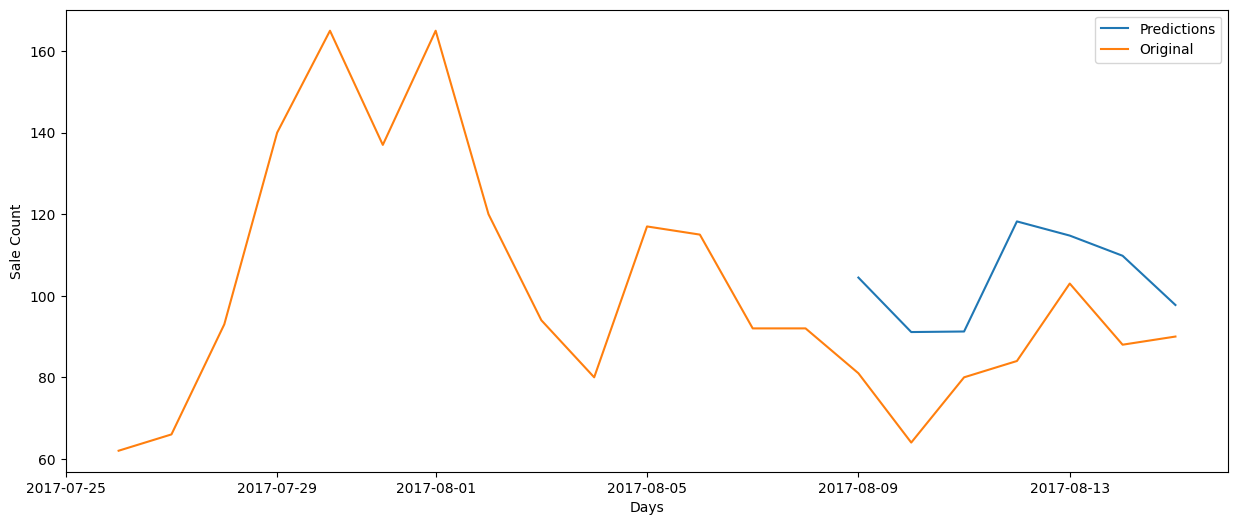

In [36]:
predict_size = 7
df = pd.DataFrame()

df["Original Values"]  = unit_sales_by_date
df["shift7"] = df["Original Values"].shift(7)
df["shift8"] = df["shift7"].shift()
df["shift9"] = df["shift8"].shift()
df["shift10"] = df["shift9"].shift()
df["shift11"] = df["shift10"].shift()
df["shift12"] = df["shift11"].shift()
df["shift13"] = df["shift12"].shift()
df.dropna(inplace=True)

x_train, y_train = df[:-predict_size].drop(["Original Values"], axis =1), df[:-predict_size]["Original Values"]
x_test, y_test  = df[-predict_size:].drop(["Original Values"], axis =1), df[-predict_size:]["Original Values"]


from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(x_train, y_train)
print(reg.coef_)
print(reg.intercept_)


ar_predictions = pd.Series(reg.predict(x_test), index=x_test.index)

plt.figure(figsize=(15,6))
plt.plot(ar_predictions ,label = "Predictions")
plt.plot(pd.concat([y_train, y_test], axis = 0)[-shown_train_size:], label = "Original" )
plt.xlabel("Days")
plt.ylabel("Sale Count")

print("mean_squared_error",mean_squared_error(y_test, ar_predictions))
print("mean_absolute_error",mean_absolute_error(y_test, ar_predictions))


plt.legend(loc="upper right")

Качество этой модели хуже предыдущей, но мы видмс, что эта модель неплохо предсказывает тенденцию, так как силуэты графиков схожи.

Итак, чтобы построить ARIMA модель нам нужно знать ее порядок, состоящий из 3-х параметров:
    
    p — порядок компоненты AR
    d — порядок интегрированного ряда
    q — порядок компонетны MA
    
d мы уже знаем - это 0

осталось определить p и q. Для их определения нам надо изучить авторкорреляционную(ACF) и частично автокорреляционную(PACF) функции для ряда первых разностей.

ACF поможет нам определить q, т. к. по ее коррелограмме можно определить количество автокорреляционных коэффициентов сильно отличных от 0 в модели MA
PACF поможет нам определить p, т. к. по ее коррелограмме можно определить максимальный номер коэффициента сильно отличный от 0 в модели AR.

Чтобы построить соответствующие коррелограммы, в пакете statsmodels имеются следующие функции: plot_acf() и plot_pacf(). Они выводят графики ACF и PACF, у которых по оси X откладываются номера лагов, а по оси Y значения соответствующих функций. Нужно отметить, что количество лагов в функциях и определяет число значимых коэффициентов.

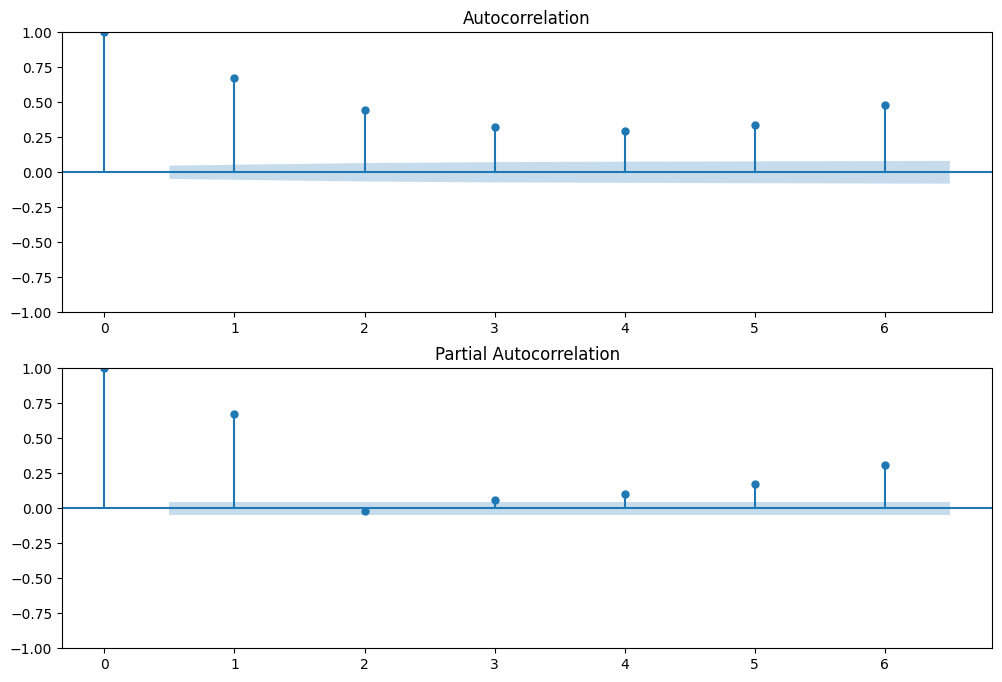

In [37]:
import statsmodels.api as sm
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(unit_sales_by_date.values.squeeze(), lags=6, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(unit_sales_by_date, lags=6, ax=ax2)

После изучения коррелограммы PACF можно сделать вывод, что p = 6, т.к. на ней все лаги сильно отличны от нуля.
По коррелограмме ACF можно предположить, что q = 6, т.к. на лаг 6 значении функций резко возрастает. Итак, когда известны все параметры можно построить модель.

## ARIMA model

In [38]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(y_train.values.reshape(-1), order=(6,0,6))

c:\Users\ekash\anaconda3\envs\sf_lightfm3\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


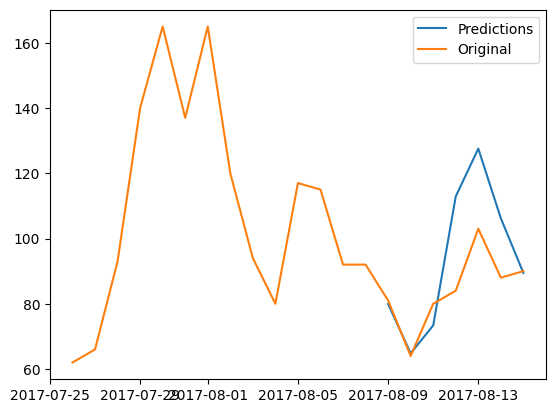

In [39]:
from statsmodels.graphics.tsaplots import plot_predict

train_size = len(y_train)
test_size = predict_size
arima_predictions = model.fit().predict(start=train_size,end=train_size+test_size -1,  dynamic=False)

plt.plot(pd.Series(arima_predictions, index=y_test.index) ,label = "Predictions")
plt.plot(pd.concat([y_train, y_test], axis = 0)[-shown_train_size:], label = "Original" )
plt.legend(loc="upper right")

In [ ]:
print("mean_squared_error",mean_squared_error(y_test, arima_predictions))
print("mean_absolute_error",mean_absolute_error(y_test, arima_predictions))


mean_squared_error 171.39367796338573
mean_absolute_error 10.507730102422299
